In [ ]:
# Program for exploring the recording database: Polish spoken words dataset (PSD). 
# Reproduces the sounds of words and presents them on charts. 
# It is possible to reproduce the sounds of entire sentences or individual phonemes.

#directory_name = "1-500"
directory_name = "501-1000"
#directory_name = "1001-1500"
#directory_name = "1501-2000"
#directory_name = "2001-2500"
#directory_name = "2501-3000"
if_chart_in_the_time_domain = True
if_spectrogram = True

import numpy as np
import matplotlib.pyplot as plt
from os.path import dirname, join as pjoin
from scipy.io import wavfile
import scipy.io
import pdb
import sounddevice as sd
import os
import torch
import torchaudio
import torchaudio.transforms as T



length = 0.7080625s, samplerate = 160001/s
cesarz
  time: start = 0.0, end = 0.69


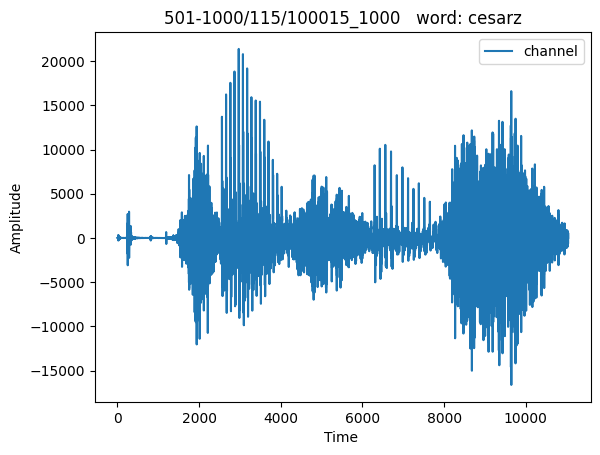

/tmp/ipykernel_21280/1816506183.py:76: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


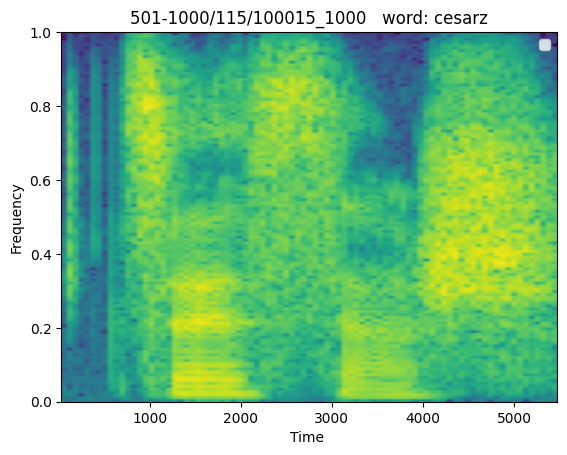

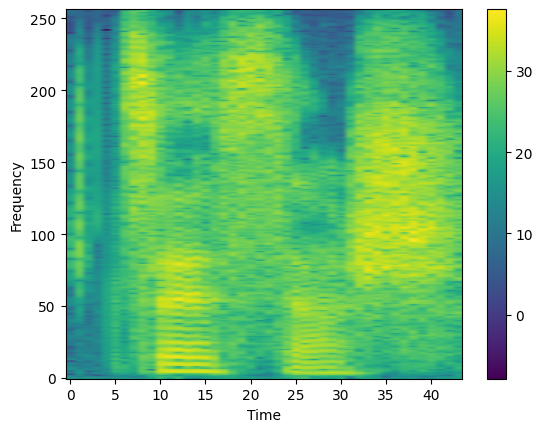

sentence 1 finished


sentence 2 finished
length = 1.67575s, samplerate = 160001/s
szczelny
  time: start = 0.0, end = 0.56


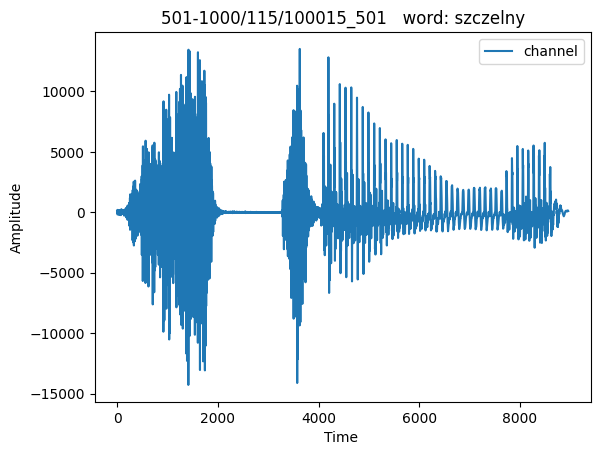

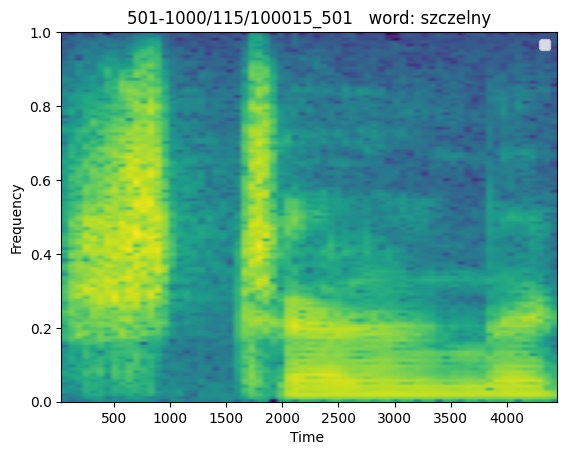

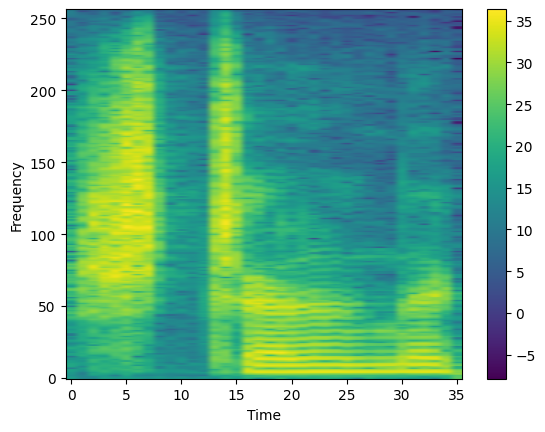

sentence 1 finished
korek
  time: start = 0.56, end = 0.95


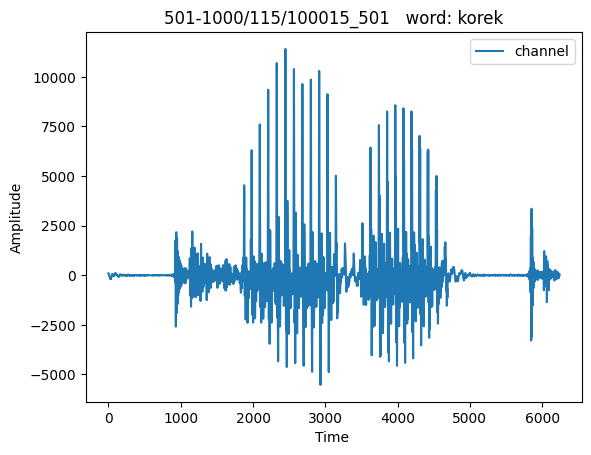

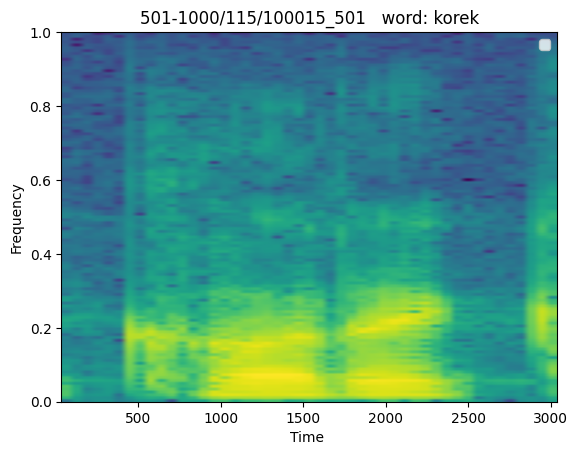

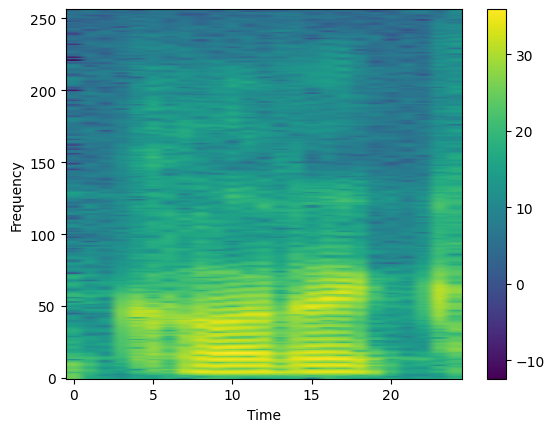

sentence 2 finished
nie
  time: start = 0.95, end = 1.19


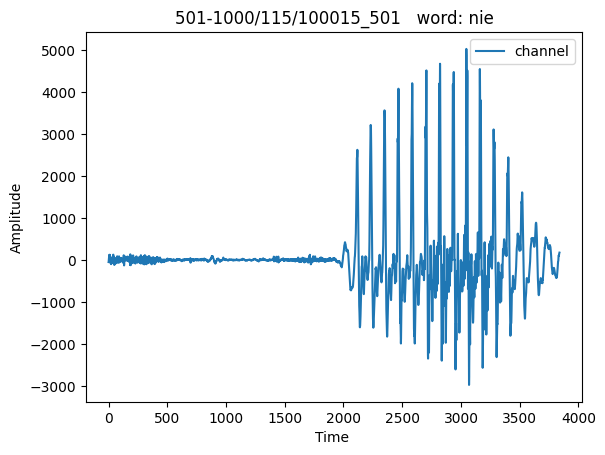

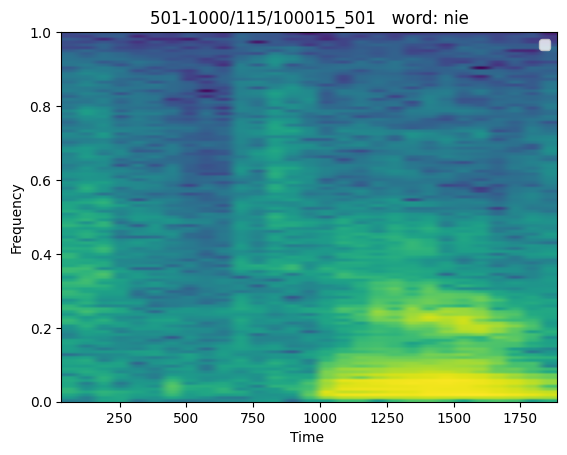

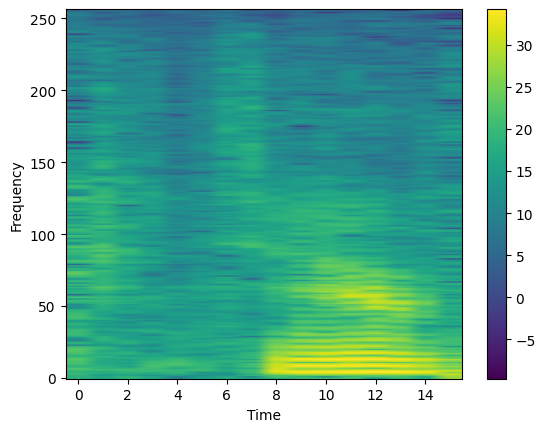

sentence 3 finished
wychodził
  time: start = 1.19, end = 1.66


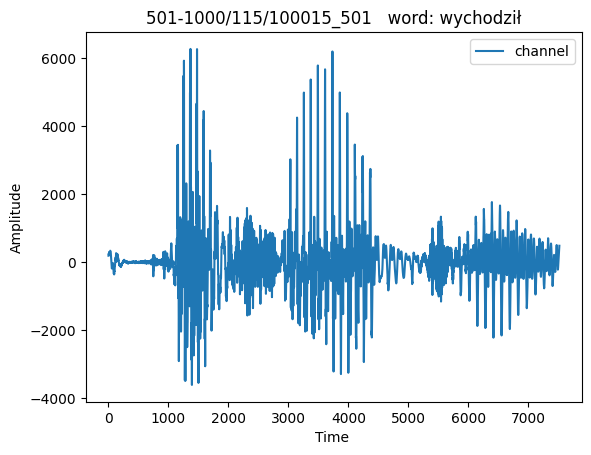

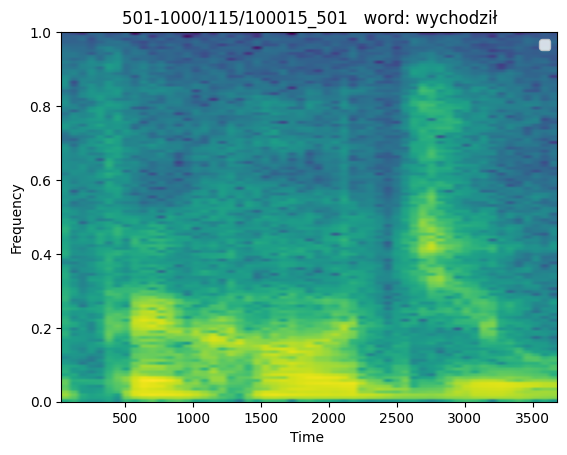

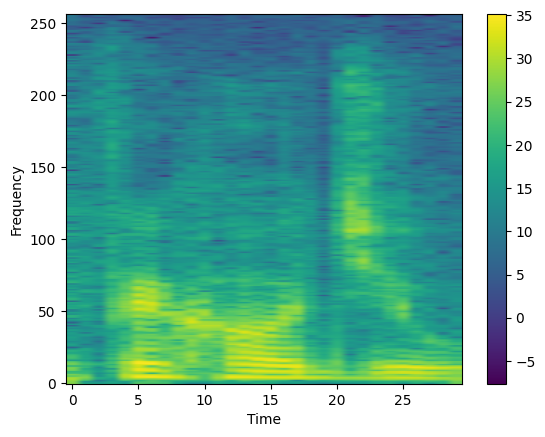

sentence 4 finished


sentence 5 finished
length = 2.191625s, samplerate = 160001/s
w
  time: start = 0.0, end = 0.03


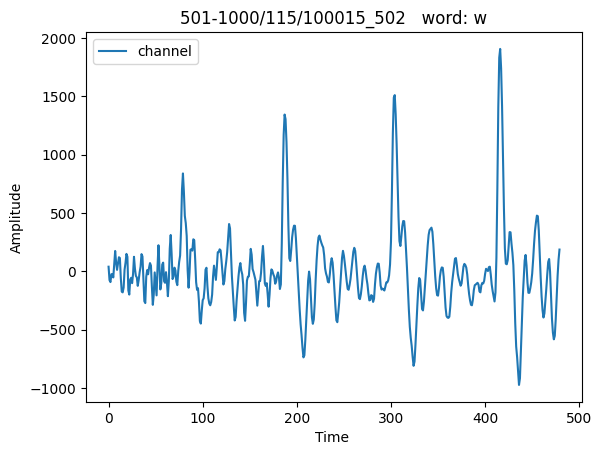

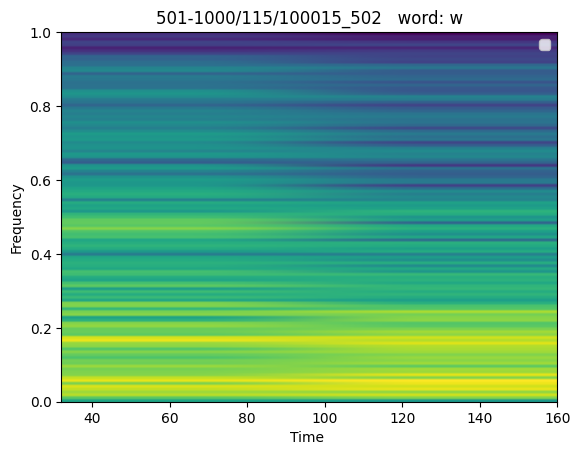

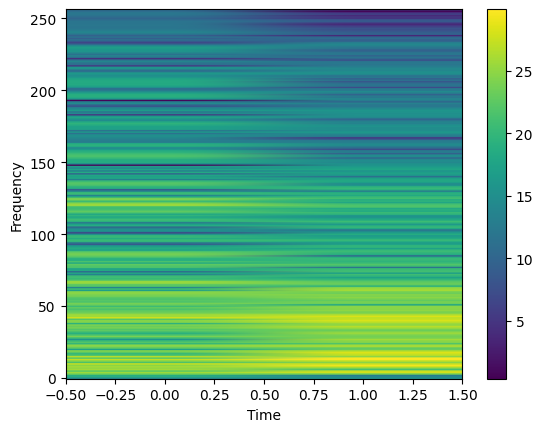

sentence 1 finished
rozdrażnieniu
  time: start = 0.03, end = 0.72


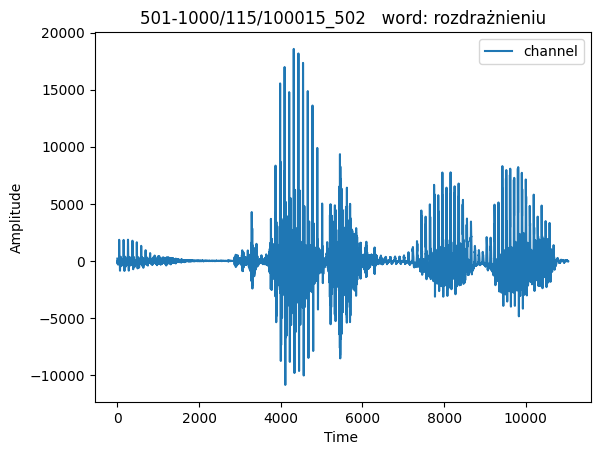

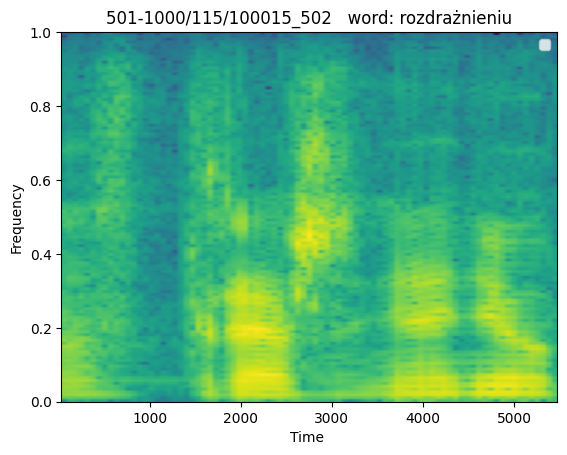

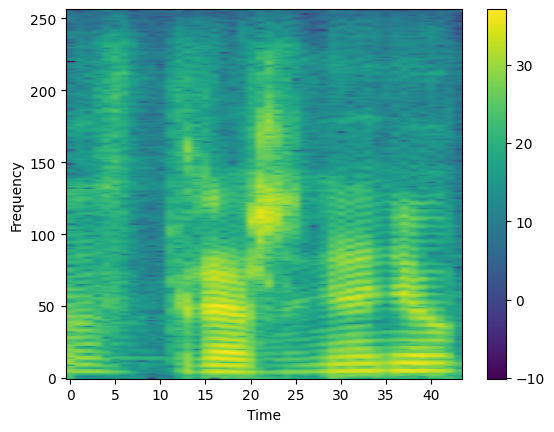

sentence 2 finished
pierre
  time: start = 0.72, end = 0.96


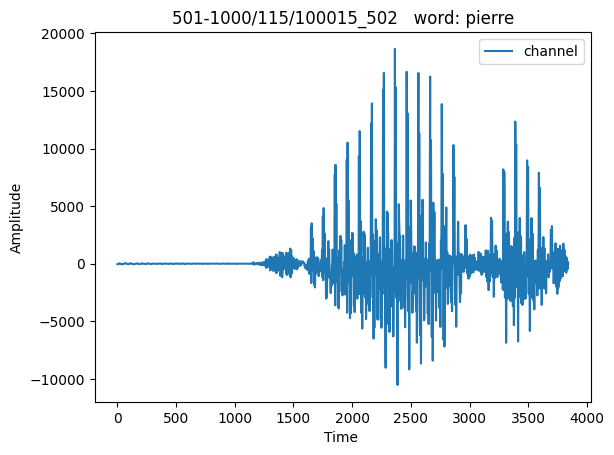

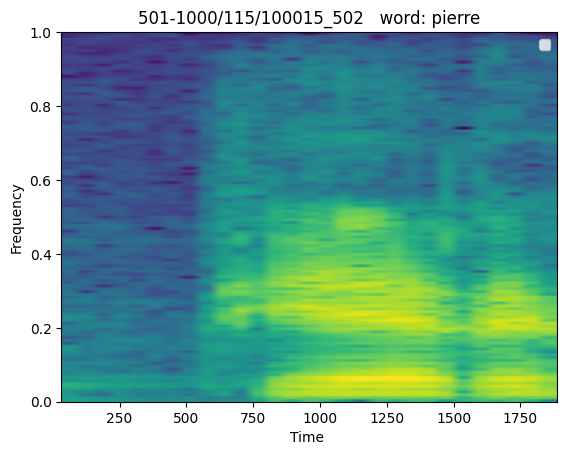

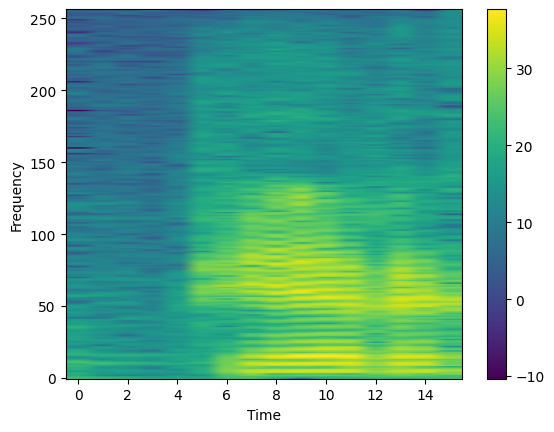

sentence 3 finished
chwycił
  time: start = 0.96, end = 1.43


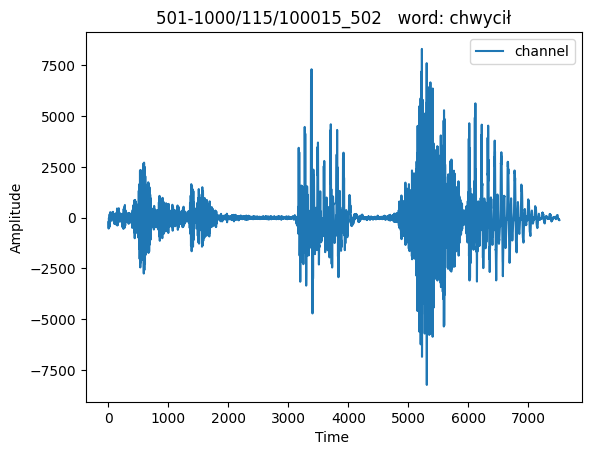

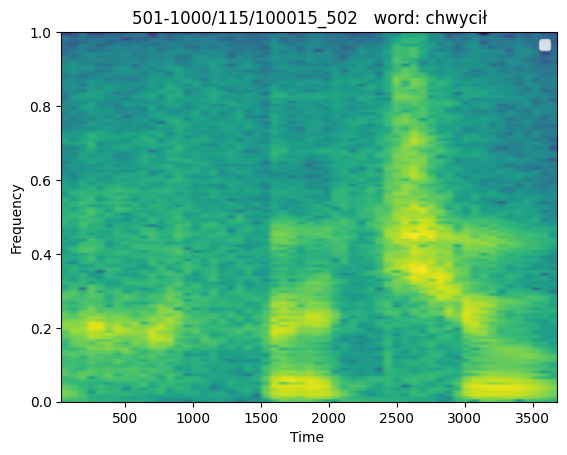

KeyboardInterrupt: 

In [30]:
punctuation_marks = [',', '.', '!', '?', ':', ';', "\""]
audios = []
author_directories = [f for f in os.listdir(directory_name) if os.path.isdir(directory_name+"/"+f)]
for aut_dir in author_directories:
    aut_path = directory_name + "/" + aut_dir
    files = [f for f in os.listdir(aut_path) if os.path.isfile(aut_path + "/" + f)]
    sentence_names = []
    for file in files:
        name_parts = file.split(".")
        if name_parts[-1] == "txt": sentence_names.append(name_parts[0])

    for sentence_name in sentence_names:
        wav_fname = aut_path + "/" + sentence_name + ".wav"
        text_file_name = aut_path + "/" + sentence_name + ".txt"
        TextGrid_file_name = aut_path + "/" + sentence_name + ".TextGrid"

        #pdb.set_trace()

        samplerate, data = wavfile.read(wav_fname)
        #pdb.set_trace()
        #print(f"number of channels = {data.shape[1]}")
        num_of_samples = data.shape[0]

        length = num_of_samples / samplerate
        print(f"length = {length}s, samplerate = {samplerate}1/s")

        text_file_ptr = open(text_file_name, 'r', encoding="utf-8")
        text = text_file_ptr.read()
        text_file_ptr.close()

        TextGrid_file_ptr = open(TextGrid_file_name, 'r', encoding="utf-8")
        text_grid = TextGrid_file_ptr.read()
        TextGrid_file_ptr.close()

        text = text.lower()
        words = text.split(' ')
        grid_lines = text_grid.split('\n')
        grid_line_index = 0                   # current line index in TextGrid file
        cleaned_words = []
        for word in words:                    # cleaning words: punctation marks removing
            while word[-1] in punctuation_marks: 
                word = word[:-1]
                if len(word) == 0: break
            if len(word) > 0: cleaned_words.append(word)
        ct = 0
        for word in cleaned_words:
            print(word)
            for i in range(len(grid_lines)-grid_line_index):
                tokens = grid_lines[i+grid_line_index].split(' ')
                if len(tokens) >= 3:
                    #print("  " + grid_lines[i+grid_line_index])
                    
                    #if (tokens[0] == "text")&(tokens[1] == "=")&(tokens[2][1:-1] == word):
                    if (tokens[1] == "=")&(tokens[2][1:-1] == word):
                        time_start = float(grid_lines[i+grid_line_index-2].split(' ')[2])
                        time_end = float(grid_lines[i+grid_line_index-1].split(' ')[2])
                        print("  time: start = " + str(time_start) + ", end = "+str(time_end))
                        sample_no_start = int(time_start/length*num_of_samples)
                        sample_no_end = int(time_end/length*num_of_samples)
                        word_data = data[sample_no_start:sample_no_end]

                        sd.play(word_data,samplerate=samplerate)

                        if if_chart_in_the_time_domain:
                            #time = np.linspace(time_start, time_end, word_data)
                            plt.plot(word_data, label="channel")
                            plt.title(aut_path + "/" + sentence_name + "   word: " + word)
                            plt.legend()
                            plt.xlabel("Time ")
                            plt.ylabel("Amplitude")
                            plt.show()

                        if if_spectrogram:
                            plt.specgram(word_data)
                            plt.title(aut_path + "/" + sentence_name + "   word: " + word)
                            plt.legend()
                            plt.xlabel("Time ")
                            plt.ylabel("Frequency")
                            plt.show()

                        waveform = torch.tensor(word_data, dtype=torch.float32)
                        waveform = waveform.unsqueeze(0)

                        # Create spectrogram transform
                        spectrogram = T.Spectrogram(n_fft=512)

                        # Apply it
                        spec = spectrogram(waveform)  # shape: (1, freq_bins, time_frames)

                        # Plot
                        plt.imshow(spec[0].log2().numpy(), aspect='auto', origin='lower')
                        plt.xlabel("Time")
                        plt.ylabel("Frequency")
                        plt.colorbar()
                        plt.show()

                        #pdb.set_trace()

                        grid_line_index += i+1
                        break
            ct += 1
            print("sentence " + str(ct) + " finished")
            if ct > 10:
                break
    break